# Evaluation

The unweighted model is fit on January–October. Its operating threshold is the delayed-class F1 peak on the pooled out-of-fold predictions from those months. November–December is drawn only after that choice.

The plots below are written by `python -m sbahn.models.evaluate`.

operating threshold 0.30  development F1 0.647  development F1 at 0.50 0.633
November–December delayed recall 0.897  on-time recall 0.992  delayed F1 0.862


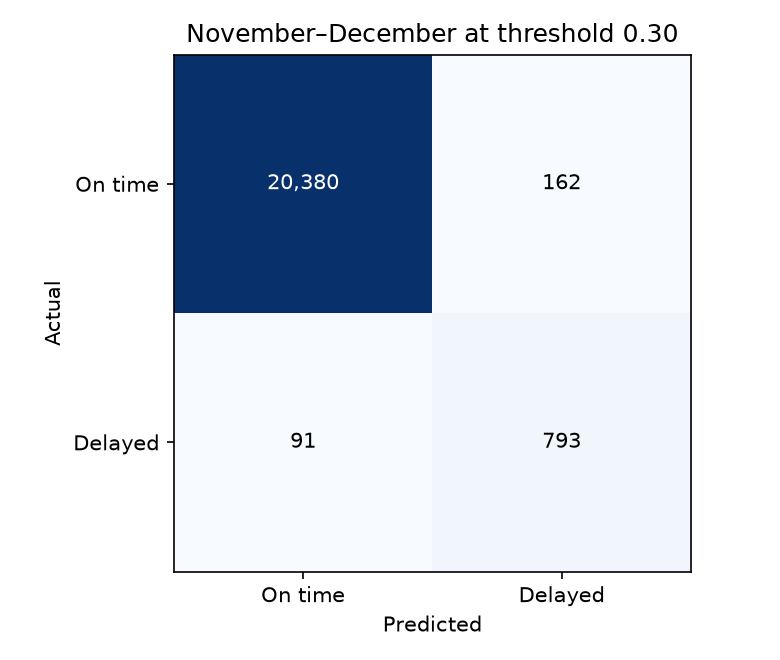

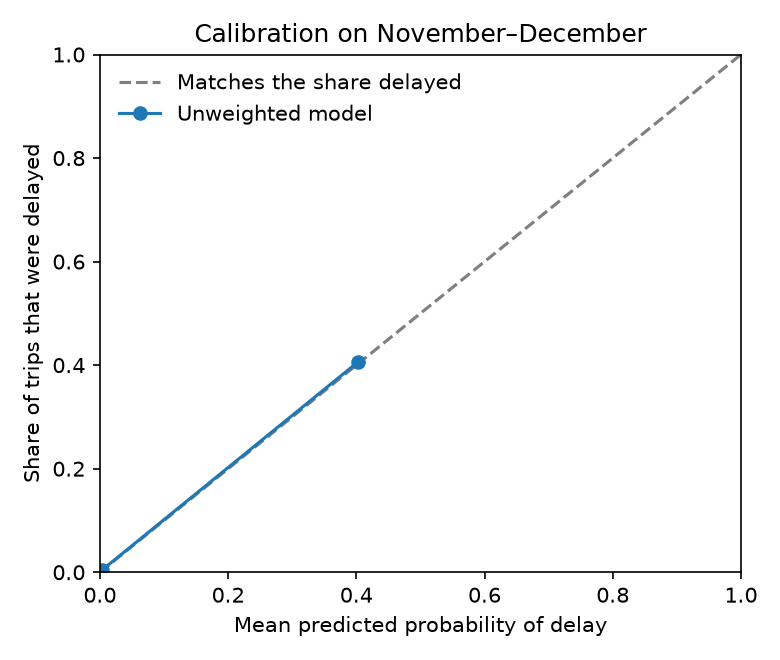

In [1]:
import json

from IPython.display import Image, display

from sbahn.config import PROJECT_ROOT

report = json.loads((PROJECT_ROOT / "reports" / "evaluation" / "operating_threshold.json").read_text(encoding="utf-8"))
print(
    f"operating threshold {report['threshold']:.2f}  "
    f"development F1 {report['development_f1']:.3f}  "
    f"development F1 at 0.50 {report['development_f1_at_0_5']:.3f}"
)
print(
    f"November–December delayed recall {report['test_recall_delayed']:.3f}  "
    f"on-time recall {report['test_recall_on_time']:.3f}  "
    f"delayed F1 {report['test_delayed_f1']:.3f}"
)
display(Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "confusion_matrix.png")))
display(Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "calibration_curve.png")))

The development F1 is highest at 0.30. The step at 0.35 is almost the same, and 0.50 is lower, so the operating cutoff moves from the search default of 0.50 to 0.30.

On November–December that cutoff catches 793 of 884 delayed trips and raises 162 false alarms. Delayed-class F1 there is 0.862, a little under the 0.874 scored at 0.50. The holdout is not used to walk the cutoff back.

On the calibration curve, nine of the ten equal-count bins sit at the origin: most trips get a probability near zero, and those trips are on time. The top bin lies on the diagonal, with a mean predicted probability of 0.40 and a delayed share of 0.41.